<a href="https://colab.research.google.com/github/Dhanavijayan/ML_OPS_Tasks/blob/main/Factory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task_1:Simple Linear Regression

Coefficient (slope): 0.0081
Intercept         : 59.8416
Baseline MSE      : 153.7556


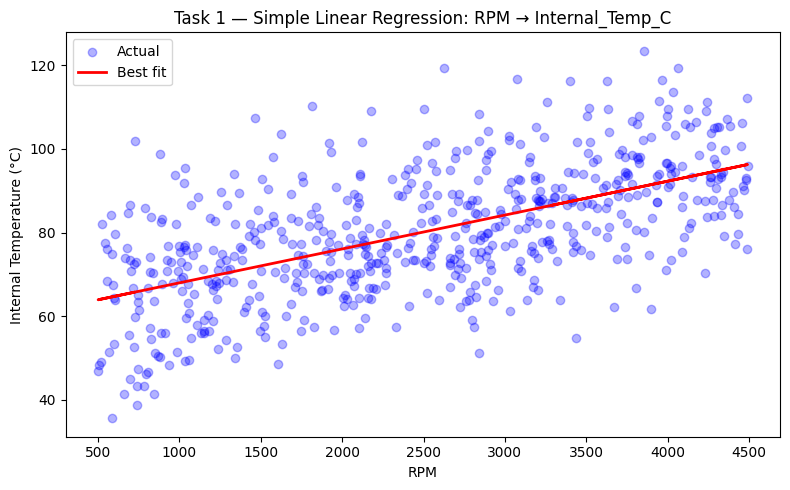

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory.csv')

X = df[['RPM']]
y = df['Internal_Temp_C']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
mse    = mean_squared_error(y, y_pred)
print(f"Coefficient (slope): {model.coef_[0]:.4f}")
print(f"Intercept         : {model.intercept_:.4f}")
print(f"Baseline MSE      : {mse:.4f}")

plt.figure(figsize=(8, 5))
plt.title('Task 1 — Simple Linear Regression: RPM → Internal_Temp_C')
plt.scatter(X, y, alpha=0.3, label='Actual', color='blue')
plt.plot(X, y_pred, color='red', linewidth=2, label='Best fit')
plt.xlabel('RPM')
plt.ylabel('Internal Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

Task_2:Multivariable Regression

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory.csv')

X1 = df[['RPM']]
y  = df['Internal_Temp_C']
m1 = LinearRegression().fit(X1, y)
mse1 = mean_squared_error(y, m1.predict(X1))

features = ['RPM', 'Vibration_Hz', 'Pressure_PSI']
X2 = df[features]
m2 = LinearRegression().fit(X2, y)
mse2 = mean_squared_error(y, m2.predict(X2))

print(f"Task 1 MSE (1 feature)  : {mse1:.4f}")
print(f"Task 2 MSE (3 features) : {mse2:.4f}")
print(f"Improvement             : {mse1 - mse2:.4f}")
print("\nCoefficients:")
for name, coef in zip(features, m2.coef_):
    print(f"  {name:15s}: {coef:.4f}")
print(f"  {'Intercept':15s}: {m2.intercept_:.4f}")

Task 1 MSE (1 feature)  : 153.7556
Task 2 MSE (3 features) : 124.2378
Improvement             : 29.5178

Coefficients:
  RPM            : 0.0080
  Vibration_Hz   : 0.1724
  Pressure_PSI   : 0.0053
  Intercept      : 48.7850


Task_3:Save Model

In [6]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression

df = pd.read_csv('factory.csv')
X  = df[['RPM', 'Vibration_Hz', 'Pressure_PSI']]
y  = df['Internal_Temp_C']

model = LinearRegression().fit(X, y)

joblib.dump(model, 'temperature_model.pkl')
print("Model saved → temperature_model.pkl")

Model saved → temperature_model.pkl


Task_4:One-Hot Encoding

In [7]:
import pandas as pd

df = pd.read_csv('factory.csv')

print("Before encoding:")
print(df['Machine_Mode'].value_counts())

df_encoded = pd.get_dummies(
    df,
    columns=['Machine_Mode'],
    drop_first=True)

print("\nNew columns after encoding:")
print([c for c in df_encoded.columns if 'Machine_Mode' in c])
print(df_encoded.head(3))

df_encoded.to_csv('factory_encoded.csv', index=False)
print("\nSaved → factory_encoded.csv")

Before encoding:
Machine_Mode
Normal         321
High-Load      156
Idle            66
Maintenance     57
Name: count, dtype: int64

New columns after encoding:
['Machine_Mode_Idle', 'Machine_Mode_Maintenance', 'Machine_Mode_Normal']
   Record_ID Machine_ID      Shift Operator_Skill Material_Type  \
0          1    MCH-007    Morning         Senior        Copper   
1          2    MCH-004  Afternoon         Senior        Copper   
2          3    MCH-008  Afternoon         Senior      Titanium   

  Coolant_Status  Ambient_Temp_C  Vibration_Hz     RPM  Pressure_PSI  \
0         Active           24.66         39.54  3291.3         54.51   
1         Active           36.36         21.11  4101.1         80.24   
2         Active           21.57         28.42  3668.8         56.36   

   Voltage_V  Humidity_Pct  Load_Pct  Internal_Temp_C Quality_Status  \
0     221.11         37.04     72.47            76.10           Pass   
1     213.74         52.04     11.45            78.97           

Task_5:Train-Test Split

In [8]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

df = pd.read_csv('factory_encoded.csv')

feature_cols = ['RPM', 'Vibration_Hz', 'Pressure_PSI',
                'Voltage_V',
                'Machine_Mode_Idle',
                'Machine_Mode_Normal']
X = df[feature_cols]
y = df['Internal_Temp_C']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train rows: {len(X_train)}  |  Test rows: {len(X_test)}")

model = LinearRegression().fit(X_train, y_train)

y_pred_test  = model.predict(X_test)
y_pred_train = model.predict(X_train)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)

print(f"MSE on training set : {mse_train:.4f}  ← NEVER report this!")
print(f"MSE on test set     : {mse_test:.4f}  ← real performance")
print(f"Gap (overfit signal): {mse_test - mse_train:.4f}")

Train rows: 480  |  Test rows: 120
MSE on training set : 111.4952  ← NEVER report this!
MSE on test set     : 106.0988  ← real performance
Gap (overfit signal): -5.3964


Task_6:Logistic Regression

Accuracy: 0.8917

Classification Report:
              precision    recall  f1-score   support

        Good       0.89      1.00      0.94       107
   Defective       0.00      0.00      0.00        13

    accuracy                           0.89       120
   macro avg       0.45      0.50      0.47       120
weighted avg       0.80      0.89      0.84       120



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


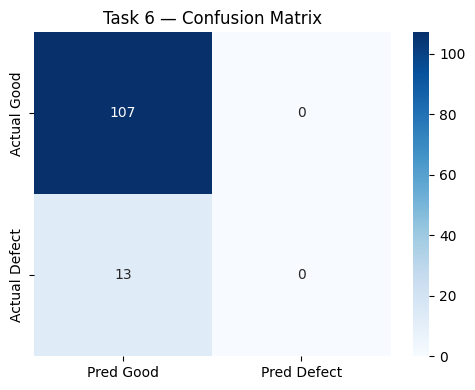

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix,
                               classification_report,
                               accuracy_score)

df = pd.read_csv('factory_encoded.csv')

df['Defective'] = (df['Quality_Status'] == 'Fail').astype(int)

feature_cols = ['RPM', 'Vibration_Hz', 'Pressure_PSI',
                'Voltage_V',
                'Machine_Mode_Idle',
                'Machine_Mode_Normal']
X = df[feature_cols]
y = df['Defective']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Good', 'Defective']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Good', 'Pred Defect'],
            yticklabels=['Actual Good', 'Actual Defect'])
plt.title('Task 6 — Confusion Matrix')
plt.tight_layout()
plt.show()